Exploring how disentagled the latent space of scVI and batch labels are based on classification performance and mutual information.

In [ ]:
import pyrootutils
root = pyrootutils.setup_root(
    search_from=".",
    indicator=".git",
    pythonpath=True,
    dotenv=True,
)

In [2]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import torch
import scvi

muris = sc.read_h5ad(str(root / 'data' / 'tabula_muris' / 'all.h5ad'))
muris.var_names_make_unique()
sc.pp.filter_cells(muris, min_genes=10)
sc.pp.filter_genes(muris, min_cells=2)

muris_10k =  muris[np.random.choice(muris.n_obs, 10000, replace=False)]
sc.pp.highly_variable_genes(muris_10k, flavor='seurat_v3', n_top_genes=2000)
muris_10k = muris_10k[:, muris_10k.var['highly_variable']].copy()  # Make a copy first
muris_10k.X = muris_10k.X.toarray()
muris_10k.X

/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/scanpy/preprocessing/_highly_variable_genes.py:178: Trying to modify attribute `._uns` of view, initializing view as actual.


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 2., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(10000, 2000), dtype=float32)

In [3]:
scvi.model.SCVI.setup_anndata(muris_10k, categorical_covariate_keys=['celltype'])
scvi_model = scvi.model.SCVI(muris_10k, use_observed_lib_size=False)
scvi_model.train()

latent = scvi_model.get_latent_representation()


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/scvi/train/_trainrunner.py:86: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/lightning/pytorch/trainer/setup.py:166: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


In [4]:
latent.shape

(10000, 10)

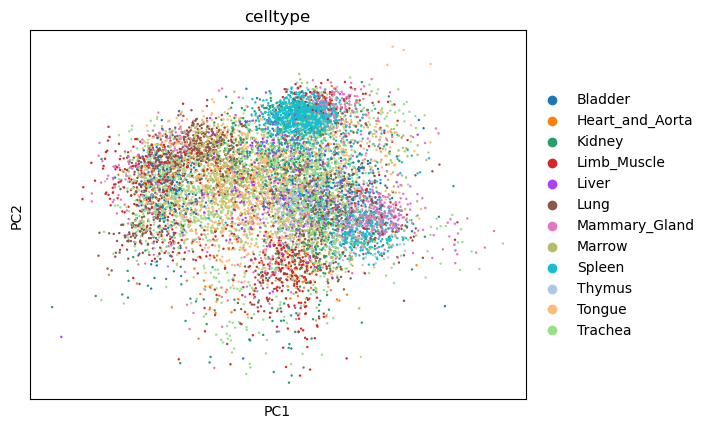

In [6]:
latent_adata = sc.AnnData(X=latent, obs=muris_10k.obs)
sc.tl.pca(latent_adata)
sc.pl.pca(latent_adata, color=['celltype'])

/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/scanpy/neighbors/__init__.py:577: You’re trying to run this on 2000 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.


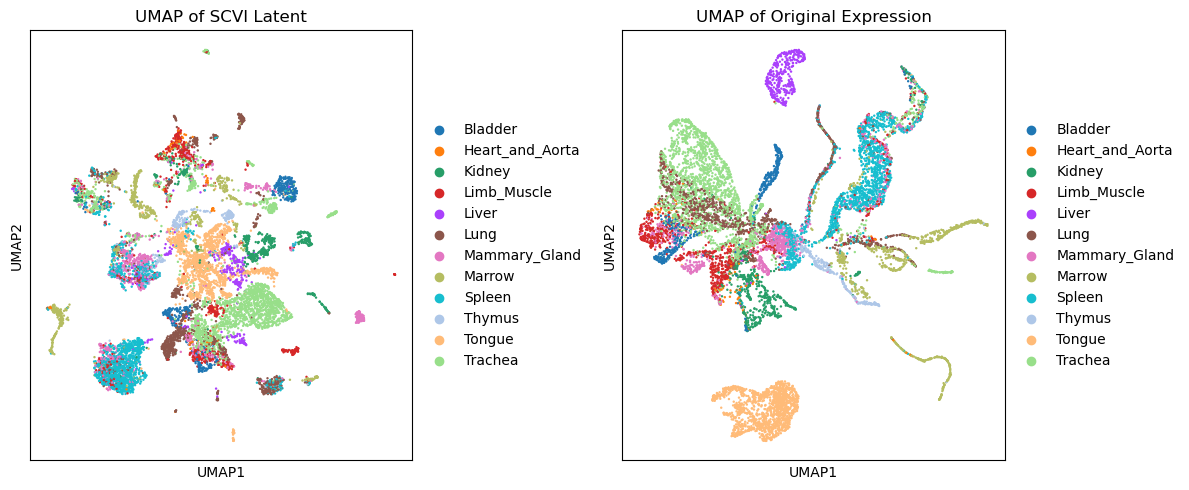

In [9]:
# Compute neighbors and UMAP for both latent and original data
sc.pp.neighbors(latent_adata, n_neighbors=10, n_pcs=50)
sc.tl.umap(latent_adata)

sc.pp.neighbors(muris_10k, n_neighbors=10, n_pcs=50)
sc.tl.umap(muris_10k)

# Prepare the figure
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot UMAP of latent representation
sc.pl.umap(latent_adata, color='celltype', show=False, ax=axs[0], title='UMAP of SCVI Latent')

# Plot UMAP of original expression
sc.pl.umap(muris_10k, color='celltype', show=False, ax=axs[1], title='UMAP of Original Expression')

plt.tight_layout()
plt.show()

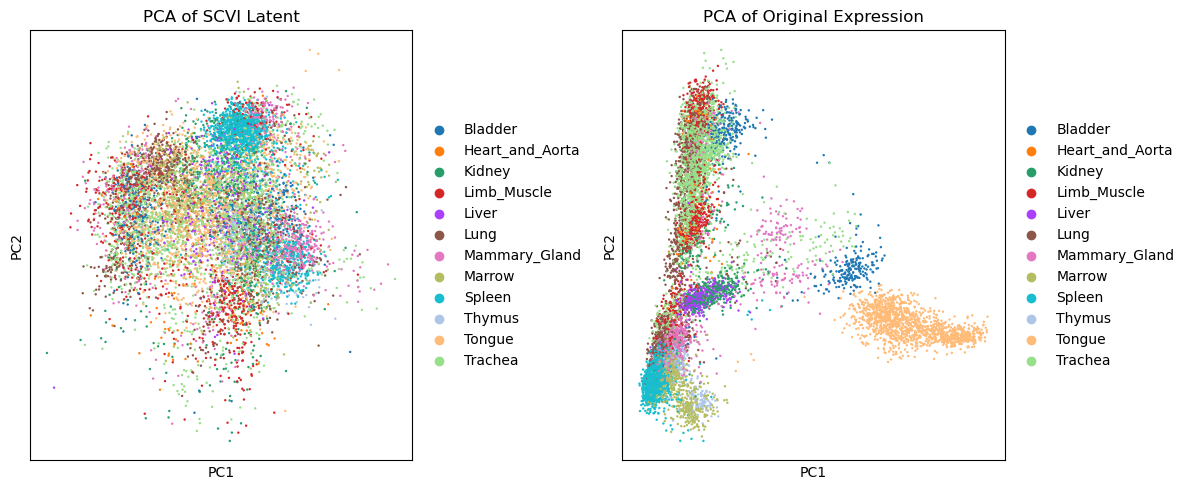

In [19]:
muris_10k.layers['counts'] = muris_10k.X.copy()
sc.pp.normalize_total(muris_10k, target_sum=1e4)
sc.pp.log1p(muris_10k)
sc.tl.pca(muris_10k)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sc.pl.pca(latent_adata, color='celltype', show=False, ax=axs[0], title='PCA of SCVI Latent')
# Plot PCA of latent representation
sc.pl.pca(muris_10k, color='celltype', show=False, ax=axs[1], title='PCA of Original Expression')

plt.tight_layout()
plt.show()

In [49]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
import numpy as np
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

# Prepare expression matrices and cell type labels
X_expr = muris_10k.X.toarray() if hasattr(muris_10k.X, "toarray") else muris_10k.X
X_latent = latent_adata.X
y = muris_10k.obs['celltype'].values

# Encode cell type labels for multiclass
lb = LabelBinarizer()
Y = lb.fit_transform(y)

# Train/test split
X_expr_train, X_expr_test, Y_train, Y_test, y_train_str, y_test_str = train_test_split(
    X_expr, Y, y, test_size=0.2, random_state=42, stratify=y
)
X_latent_train, X_latent_test = train_test_split(
    X_latent, test_size=0.2, random_state=42, stratify=y
)

# Helper to train and evaluate classifier
def train_and_eval(X_train, X_test, Y_train, Y_test, y_train_str, y_test_str, label=""):
    rf = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)
    rf.fit(X_train, np.argmax(Y_train, axis=1))
    y_pred_proba = rf.predict_proba(X_test)
    y_pred = rf.predict(X_test)
    # Multiclass AUC (macro)
    try:
        auc = roc_auc_score(Y_test, y_pred_proba, multi_class='ovr', average='macro')
    except Exception:
        auc = np.nan
    acc = accuracy_score(np.argmax(Y_test, axis=1), y_pred)
    print(f"{label} classifier --- AUC: {auc:.3f}, Accuracy: {acc:.3f}")
    return auc, acc

print("Random Forest classifiers to predict celltype:\n")

auc_expr, acc_expr = train_and_eval(
    X_expr_train, X_expr_test, Y_train, Y_test, y_train_str, y_test_str, label='Expression'
)

auc_latent, acc_latent = train_and_eval(
    X_latent_train, X_latent_test, Y_train, Y_test, y_train_str, y_test_str, label='Latent (scVI)'
)

Random Forest classifiers to predict celltype:

Expression classifier --- AUC: 0.999, Accuracy: 0.971
Latent (scVI) classifier --- AUC: 0.979, Accuracy: 0.830


It seems that they are not that disentangled.

In [ ]:
from sklearn.preprocessing import LabelEncoder  # noqa: E402
from sklearn.feature_selection import mutual_info_classif

y_labels = muris_10k.obs['celltype'].values

le = LabelEncoder()
y_int = le.fit_transform(y_labels)

# For observed expression data
mi_expr = mutual_info_classif(X_expr, y_int, discrete_features=False, random_state=0)
print(f"Max mutual information for muris_10k (expression X): {np.max(mi_expr):.4f}")

mi_latent = mutual_info_classif(X_latent, y_int, discrete_features=False, random_state=0)
print(f"Max mutual information for latent_adata (scVI Z): {np.max(mi_latent):.4f}")


Mutual information (mean across features):
Max mutual information for muris_10k (expression X): 0.5785
Max mutual information for latent_adata (scVI Z): 0.1855


In [52]:
import numpy as np
import pandas as pd
import scanpy as sc
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import silhouette_samples


def _get_representation(adata, prefer_obsm_keys=("X_latent", "X_scVI", "X_umap", "X_pca"), n_pcs=50):
    """
    Pick a numeric representation matrix for metrics.
    Priority:
      1) first existing key in adata.obsm among prefer_obsm_keys
      2) if adata.obsm['X_pca'] exists, use it
      3) else compute PCA on adata.X and use adata.obsm['X_pca']
    Returns: (X_rep, rep_name)
    """
    for k in prefer_obsm_keys:
        if k in adata.obsm and adata.obsm[k] is not None:
            X = adata.obsm[k]
            return np.asarray(X), f"obsm[{k}]"

    if "X_pca" in adata.obsm and adata.obsm["X_pca"] is not None:
        return np.asarray(adata.obsm["X_pca"]), "obsm[X_pca]"

    # Compute PCA on X (works for sparse too)
    sc.pp.pca(adata, n_comps=n_pcs, use_highly_variable=False, svd_solver="arpack")
    return np.asarray(adata.obsm["X_pca"]), f"computed PCA (n_pcs={n_pcs})"


def pcr_batch_score(X, batch):
    """
    PCR batch metric as described in Luecken et al.:
      Var(C|B) = sum_i (Var explained by PC_i) * R^2(PC_i ~ batch)
    Here X is already a low-dim representation (e.g., PCA coords or latent).
    If X is PCA coords, we approximate Var(C|PC_i) by variance ratio from X itself.

    Returns:
      var_explained_by_batch: float (higher => batch explains more => worse batch removal)
      details_df: per-dimension R^2 and weights
    """
    batch = np.asarray(batch).reshape(-1, 1)

    # One-hot encode batch categories
    enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    B = enc.fit_transform(batch)

    # Weight per dimension: variance ratio in X
    var = np.var(X, axis=0, ddof=1)
    total_var = var.sum()
    if total_var <= 0:
        raise ValueError("Representation has zero total variance; cannot compute PCR.")

    weights = var / total_var

    r2_list = []
    lr = LinearRegression()
    for i in range(X.shape[1]):
        y = X[:, i]
        lr.fit(B, y)
        r2 = lr.score(B, y)  # R^2
        r2_list.append(r2)

    r2 = np.array(r2_list)
    var_explained_by_batch = float(np.sum(weights * r2))

    details_df = pd.DataFrame(
        {
            "dim": np.arange(X.shape[1]),
            "weight_var_ratio": weights,
            "r2_dim_on_batch": r2,
            "weighted_r2": weights * r2,
        }
    )
    return var_explained_by_batch, details_df


def asw_batch_score(X, batch, group=None):
    """
    Batch ASW in spirit of the paper:
      - If group is provided: compute silhouette on batch within each group, then average across groups.
      - If group is None: compute silhouette on batch globally.

    The paper uses abs(silhouette) and then 1 - abs(silhouette), so higher is "more mixed".
    Returns:
      asw_score: float in [0,1] approximately (higher => more mixed w.r.t. batch)
    """
    batch = pd.Categorical(batch)
    if batch.categories.size < 2:
        return np.nan

    def _score_subset(idx):
        # Need at least 2 samples per batch label in subset for silhouette to behave well
        b = batch[idx]
        if pd.Categorical(b).categories.size < 2:
            return np.nan
        # silhouette requires at least 2 labels present and at least 2 samples overall
        if len(idx) < 3:
            return np.nan
        s = silhouette_samples(X[idx], b, metric="euclidean")
        return float(np.mean(1.0 - np.abs(s)))

    if group is None:
        idx = np.arange(X.shape[0])
        return _score_subset(idx)

    group = pd.Categorical(group)
    scores = []
    for g in group.categories:
        idx = np.where(group == g)[0]
        sc_ = _score_subset(idx)
        if not np.isnan(sc_):
            scores.append(sc_)
    return float(np.mean(scores)) if len(scores) else np.nan


def evaluate_adata(adata, name, batch_key="celltype", group_key=None, n_pcs_if_needed=50):
    if batch_key not in adata.obs:
        raise KeyError(f"{name}: obs['{batch_key}'] not found.")

    X, rep_name = _get_representation(adata, n_pcs=n_pcs_if_needed)

    batch = adata.obs[batch_key].values
    group = adata.obs[group_key].values if (group_key is not None and group_key in adata.obs) else None

    pcr, pcr_details = pcr_batch_score(X, batch)
    asw = asw_batch_score(X, batch, group=group)

    summary = {
        "dataset": name,
        "rep_used": rep_name,
        "n_cells": adata.n_obs,
        "n_dims": X.shape[1],
        "batch_key": batch_key,
        "n_batch_categories": pd.Categorical(batch).categories.size,
        "group_key": group_key if group is not None else None,
        "PCR_VarExplainedByBatch": pcr,   # higher = more batch signal remains (worse removal)
        "ASW_batch_mixing": asw,          # higher = more mixing w.r.t. batch labels
    }
    return summary, pcr_details


# =======================
# Main: run on your objects
# =======================

# Assumes you already have muris_10k and latent_adata in memory as AnnData objects.

batch_key = "celltype"

# If you actually have another biological label column (e.g., "cell_identity" / "annotation" / "subtype"),
# set group_key to that to mimic the paper's "within-celltype" stratification.
group_key = None  # e.g., "cell_identity"

summaries = []
details = {}

for ad, nm in [(muris_10k, "muris_10k"), (latent_adata, "latent_adata")]:
    s, d = evaluate_adata(ad, nm, batch_key=batch_key, group_key=group_key, n_pcs_if_needed=50)
    summaries.append(s)
    details[nm] = d

summary_df = pd.DataFrame(summaries)
print("\n=== Summary (celltype treated as batch) ===")
print(summary_df.to_string(index=False))

# Optional: save results
# summary_df.to_csv("batch_metrics_summary.csv", index=False)
# details["muris_10k"].to_csv("pcr_details_muris_10k.csv", index=False)
# details["latent_adata"].to_csv("pcr_details_latent_adata.csv", index=False)

# Optional: peek at top dims contributing to PCR
for nm in details:
    df = details[nm].sort_values("weighted_r2", ascending=False).head(10)
    print(f"\n=== Top 10 dims by weighted R^2 for {nm} ===")
    print(df.to_string(index=False))



=== Summary (celltype treated as batch) ===
     dataset     rep_used  n_cells  n_dims batch_key  n_batch_categories group_key  PCR_VarExplainedByBatch  ASW_batch_mixing
   muris_10k obsm[X_umap]    10000       2  celltype                  12      None                 0.634962          0.651890
latent_adata obsm[X_umap]    10000       2  celltype                  12      None                 0.231773          0.730716

=== Top 10 dims by weighted R^2 for muris_10k ===
 dim  weight_var_ratio  r2_dim_on_batch  weighted_r2
   1          0.542301         0.753254     0.408491
   0          0.457698         0.494805     0.226472

=== Top 10 dims by weighted R^2 for latent_adata ===
 dim  weight_var_ratio  r2_dim_on_batch  weighted_r2
   0          0.445984         0.313179     0.139673
   1          0.554016         0.166241     0.092100
